# **IMPORT LIBRARIES**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# **IMPORT DATASET**

In [2]:
Train= pd.read_csv('../input/house-prices-advanced-regression-techniques/train.csv')
Test= pd.read_csv('../input/house-prices-advanced-regression-techniques/test.csv')

# **DATA OVERVIWE**

In [3]:
Train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:
Train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [5]:
Train.shape

(1460, 81)

In [6]:
Train.corr()['SalePrice'].sort_values()

KitchenAbvGr    -0.135907
EnclosedPorch   -0.128578
MSSubClass      -0.084284
OverallCond     -0.077856
YrSold          -0.028923
LowQualFinSF    -0.025606
Id              -0.021917
MiscVal         -0.021190
BsmtHalfBath    -0.016844
BsmtFinSF2      -0.011378
3SsnPorch        0.044584
MoSold           0.046432
PoolArea         0.092404
ScreenPorch      0.111447
BedroomAbvGr     0.168213
BsmtUnfSF        0.214479
BsmtFullBath     0.227122
LotArea          0.263843
HalfBath         0.284108
OpenPorchSF      0.315856
2ndFlrSF         0.319334
WoodDeckSF       0.324413
LotFrontage      0.351799
BsmtFinSF1       0.386420
Fireplaces       0.466929
MasVnrArea       0.477493
GarageYrBlt      0.486362
YearRemodAdd     0.507101
YearBuilt        0.522897
TotRmsAbvGrd     0.533723
FullBath         0.560664
1stFlrSF         0.605852
TotalBsmtSF      0.613581
GarageArea       0.623431
GarageCars       0.640409
GrLivArea        0.708624
OverallQual      0.790982
SalePrice        1.000000
Name: SalePr

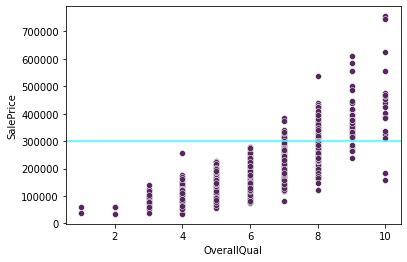

In [7]:
sns.scatterplot(data=Train, x='OverallQual', y='SalePrice', color='#56275c')
plt.axhline(y=300000 , color='#38ffff')

In [8]:
Train[(Train['OverallQual']>8) & (Train['SalePrice']<200000)][['SalePrice', 'OverallQual']]

,SalePrice,OverallQual
523,184750,10
1298,160000,10


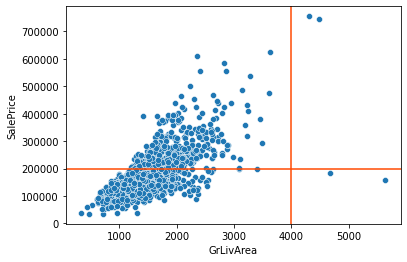

In [9]:
sns.scatterplot(data= Train, x='GrLivArea', y='SalePrice')
plt.axhline(y=200000, color='#ff4800')
plt.axvline(x=4000, color='#ff4800')

In [10]:
index_drop=Train[(Train['GrLivArea']>4000) & (Train['SalePrice']<200000)].index

In [11]:
index_drop

Int64Index([523, 1298], dtype='int64')

In [12]:
Train= Train.drop(index_drop)

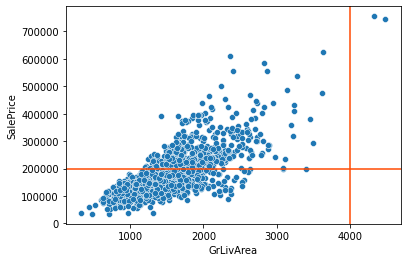

In [13]:
sns.scatterplot(data=Train, x='GrLivArea', y='SalePrice')
plt.axhline(y=200000, color='#ff4800')
plt.axvline(x=4000, color='#ff4800')

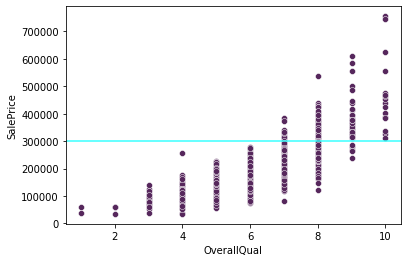

In [14]:
sns.scatterplot(data=Train, x='OverallQual', y='SalePrice', color='#56275c')
plt.axhline(y=300000 , color='#38ffff')

<AxesSubplot:xlabel='OverallQual', ylabel='SalePrice'>

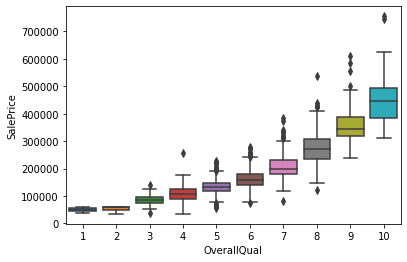

In [15]:
sns.boxplot(data=Train, x='OverallQual', y='SalePrice')

In [16]:
with open('../input/featur/Ames_Housing_Feature_Description.txt', 'r') as f:
    print(f.read())

MSSubClass: Identifies the type of dwelling involved in the sale.	

        20	1-STORY 1946 & NEWER ALL STYLES
        30	1-STORY 1945 & OLDER
        40	1-STORY W/FINISHED ATTIC ALL AGES
        45	1-1/2 STORY - UNFINISHED ALL AGES
        50	1-1/2 STORY FINISHED ALL AGES
        60	2-STORY 1946 & NEWER
        70	2-STORY 1945 & OLDER
        75	2-1/2 STORY ALL AGES
        80	SPLIT OR MULTI-LEVEL
        85	SPLIT FOYER
        90	DUPLEX - ALL STYLES AND AGES
       120	1-STORY PUD (Planned Unit Development) - 1946 & NEWER
       150	1-1/2 STORY PUD - ALL AGES
       160	2-STORY PUD - 1946 & NEWER
       180	PUD - MULTILEVEL - INCL SPLIT LEV/FOYER
       190	2 FAMILY CONVERSION - ALL STYLES AND AGES

MSZoning: Identifies the general zoning classification of the sale.
		
       A	Agriculture
       C	Commercial
       FV	Floating Village Residential
       I	Industrial
       RH	Residential High Density
       RL	Residential Low Density
       RP	Residential Low Density Park 
       RM

In [17]:
Train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [18]:
Train= Train.drop('Id', axis=1)

In [19]:
(Train.isnull().sum()/len (Train))*100

MSSubClass        0.00000
MSZoning          0.00000
LotFrontage      17.76406
LotArea           0.00000
Street            0.00000
                   ...   
MoSold            0.00000
YrSold            0.00000
SaleType          0.00000
SaleCondition     0.00000
SalePrice         0.00000
Length: 80, dtype: float64

In [20]:
def missing_percent (Train):
    nan_percent= (Train.isnull().sum()/len (Train))*100
    nan_percent= nan_percent[nan_percent>0].sort_values()
    return nan_percent

In [21]:
nan_percent= missing_percent(Train)

In [22]:
nan_percent

Electrical       0.068587
MasVnrType       0.548697
MasVnrArea       0.548697
BsmtQual         2.537723
BsmtCond         2.537723
BsmtFinType1     2.537723
BsmtExposure     2.606310
BsmtFinType2     2.606310
GarageCond       5.555556
GarageQual       5.555556
GarageFinish     5.555556
GarageType       5.555556
GarageYrBlt      5.555556
LotFrontage     17.764060
FireplaceQu     47.325103
Fence           80.727023
Alley           93.758573
MiscFeature     96.296296
PoolQC          99.588477
dtype: float64

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
        17, 18]),
 [Text(0, 0, 'Electrical'),
  Text(1, 0, 'MasVnrType'),
  Text(2, 0, 'MasVnrArea'),
  Text(3, 0, 'BsmtQual'),
  Text(4, 0, 'BsmtCond'),
  Text(5, 0, 'BsmtFinType1'),
  Text(6, 0, 'BsmtExposure'),
  Text(7, 0, 'BsmtFinType2'),
  Text(8, 0, 'GarageCond'),
  Text(9, 0, 'GarageQual'),
  Text(10, 0, 'GarageFinish'),
  Text(11, 0, 'GarageType'),
  Text(12, 0, 'GarageYrBlt'),
  Text(13, 0, 'LotFrontage'),
  Text(14, 0, 'FireplaceQu'),
  Text(15, 0, 'Fence'),
  Text(16, 0, 'Alley'),
  Text(17, 0, 'MiscFeature'),
  Text(18, 0, 'PoolQC')])

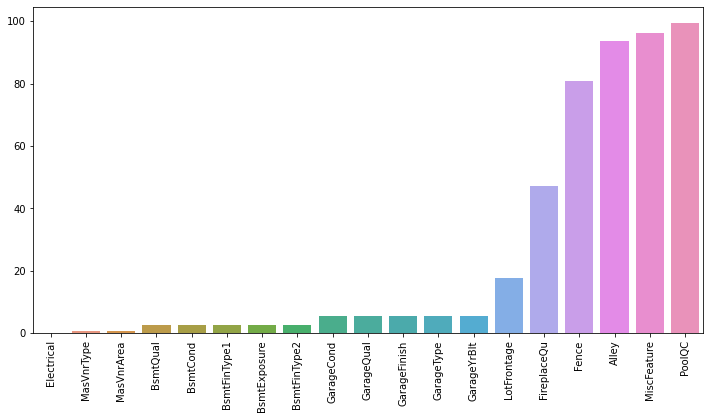

In [23]:
plt.figure(figsize=(12, 6))
sns.barplot(x= nan_percent.index, y= nan_percent)
plt.xticks(rotation=90)

(0.0, 1.0)

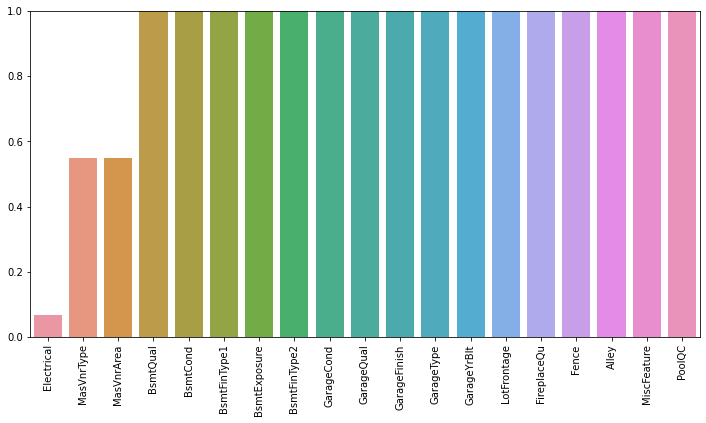

In [24]:
plt.figure(figsize=(12, 6))
sns.barplot(x= nan_percent.index, y= nan_percent)
plt.xticks(rotation=90)
plt.ylim(0, 1)

In [25]:
Train[Train['Electrical'].isnull()]

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1379,80,RL,73.0,9735,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,5,2008,WD,Normal,167500


In [26]:
Train= Train.dropna(subset=['Electrical'], axis=0)

(0.0, 1.0)

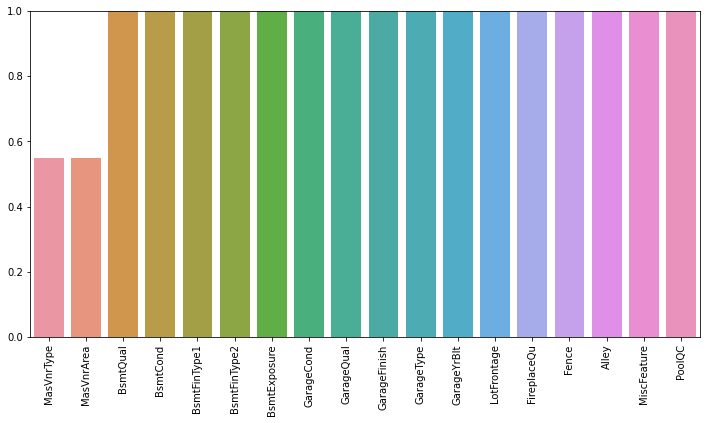

In [27]:
nan_percent= missing_percent(Train)

plt.figure(figsize=(12, 6))
sns.barplot(x= nan_percent.index, y= nan_percent)
plt.xticks(rotation=90)
plt.ylim(0, 1)

In [28]:
Train['MasVnrType']= Train['MasVnrType'].fillna("None")
Train['MasVnrArea']= Train['MasVnrArea'].fillna(0)

(0.0, 1.0)

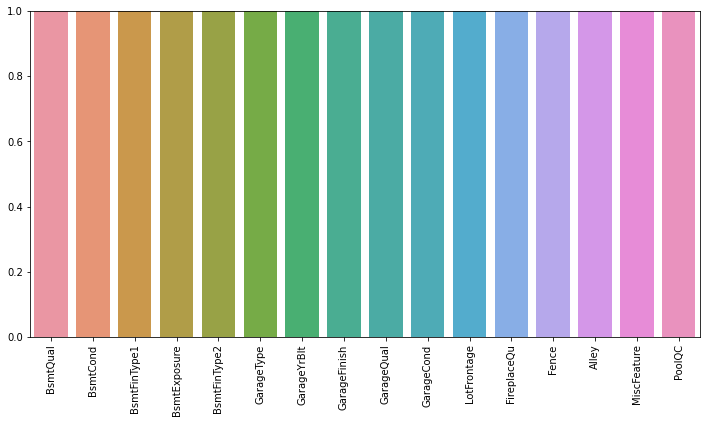

In [29]:
nan_percent= missing_percent(Train)

plt.figure(figsize=(12, 6))
sns.barplot(x= nan_percent.index, y= nan_percent)
plt.xticks(rotation=90)
plt.ylim(0, 1)

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15]),
 [Text(0, 0, 'BsmtQual'),
  Text(1, 0, 'BsmtCond'),
  Text(2, 0, 'BsmtFinType1'),
  Text(3, 0, 'BsmtExposure'),
  Text(4, 0, 'BsmtFinType2'),
  Text(5, 0, 'GarageType'),
  Text(6, 0, 'GarageYrBlt'),
  Text(7, 0, 'GarageFinish'),
  Text(8, 0, 'GarageQual'),
  Text(9, 0, 'GarageCond'),
  Text(10, 0, 'LotFrontage'),
  Text(11, 0, 'FireplaceQu'),
  Text(12, 0, 'Fence'),
  Text(13, 0, 'Alley'),
  Text(14, 0, 'MiscFeature'),
  Text(15, 0, 'PoolQC')])

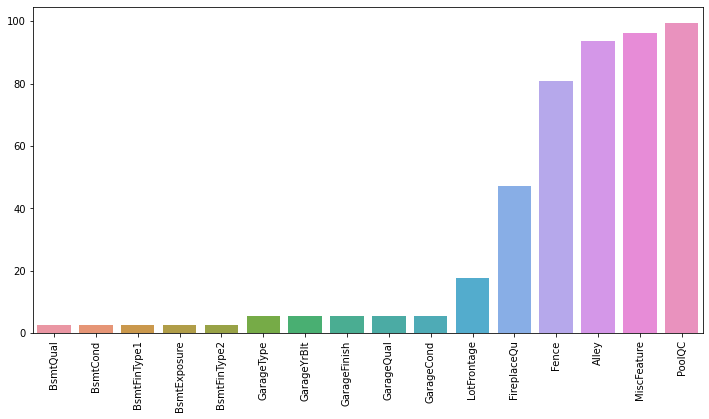

In [30]:
nan_percent= missing_percent(Train)

plt.figure(figsize=(12, 6))
sns.barplot(x= nan_percent.index, y= nan_percent)
plt.xticks(rotation=90)

In [31]:
Bsmt_num_cols= ['BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'BsmtFullBath'] 
Train[Bsmt_num_cols]= Train[Bsmt_num_cols].fillna(0) 

Bsmt_str_cols= ['BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2']
Train[Bsmt_str_cols]= Train[Bsmt_str_cols].fillna('None')

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10]),
 [Text(0, 0, 'GarageType'),
  Text(1, 0, 'GarageYrBlt'),
  Text(2, 0, 'GarageFinish'),
  Text(3, 0, 'GarageQual'),
  Text(4, 0, 'GarageCond'),
  Text(5, 0, 'LotFrontage'),
  Text(6, 0, 'FireplaceQu'),
  Text(7, 0, 'Fence'),
  Text(8, 0, 'Alley'),
  Text(9, 0, 'MiscFeature'),
  Text(10, 0, 'PoolQC')])

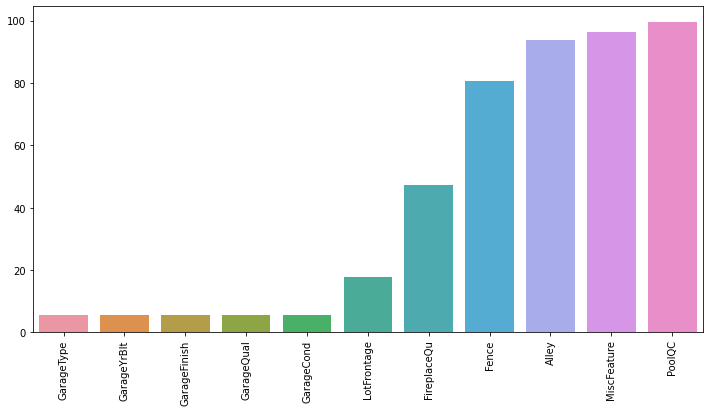

In [32]:
nan_percent= missing_percent(Train)

plt.figure(figsize=(12, 6))
sns.barplot(x= nan_percent.index, y= nan_percent)
plt.xticks(rotation=90)

In [33]:
Gar_str_cols= ['GarageType', 'GarageFinish', 'GarageQual', 'GarageCond']
Train[Gar_str_cols]= Train[Gar_str_cols].fillna('None')

Train['GarageYrBlt']= Train['GarageYrBlt'].fillna(0) 

(array([0, 1, 2, 3, 4, 5]),
 [Text(0, 0, 'LotFrontage'),
  Text(1, 0, 'FireplaceQu'),
  Text(2, 0, 'Fence'),
  Text(3, 0, 'Alley'),
  Text(4, 0, 'MiscFeature'),
  Text(5, 0, 'PoolQC')])

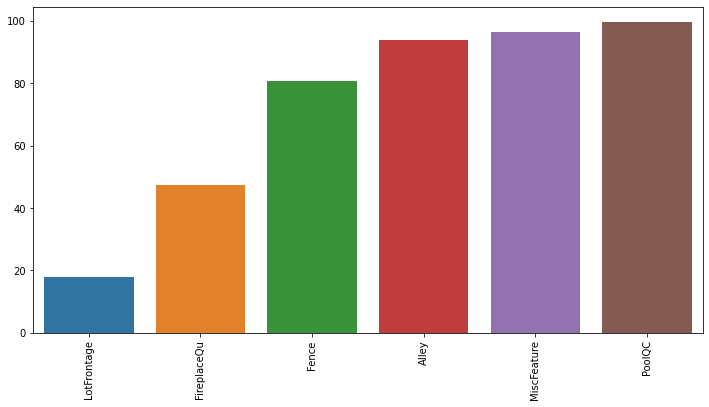

In [34]:
nan_percent= missing_percent(Train)

plt.figure(figsize=(12, 6))
sns.barplot(x= nan_percent.index, y= nan_percent)
plt.xticks(rotation=90)

In [35]:
Train= Train.drop(['Fence', 'Alley', 'MiscFeature', 'PoolQC'], axis=1)

(array([0, 1]), [Text(0, 0, 'LotFrontage'), Text(1, 0, 'FireplaceQu')])

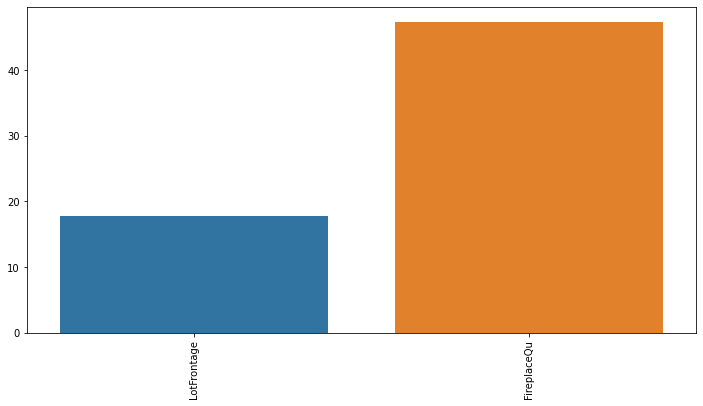

In [36]:
nan_percent= missing_percent(Train)

plt.figure(figsize=(12, 6))
sns.barplot(x= nan_percent.index, y= nan_percent)
plt.xticks(rotation=90)

In [37]:
Train['FireplaceQu']= Train['FireplaceQu'].fillna('None')

(array([0]), [Text(0, 0, 'LotFrontage')])

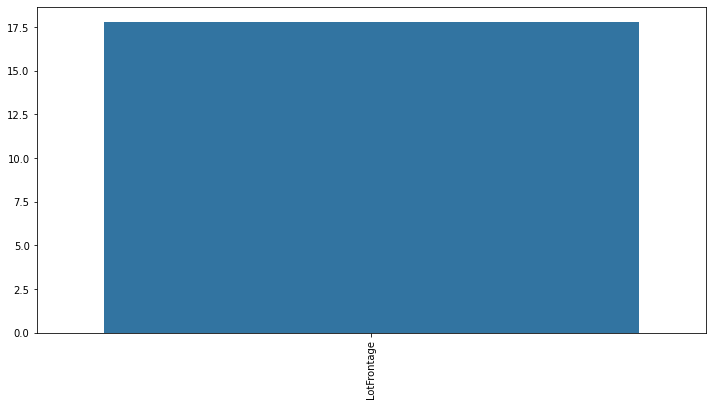

In [38]:
nan_percent= missing_percent(Train)

plt.figure(figsize=(12, 6))
sns.barplot(x= nan_percent.index, y= nan_percent)
plt.xticks(rotation=90)

<AxesSubplot:xlabel='LotFrontage', ylabel='Neighborhood'>

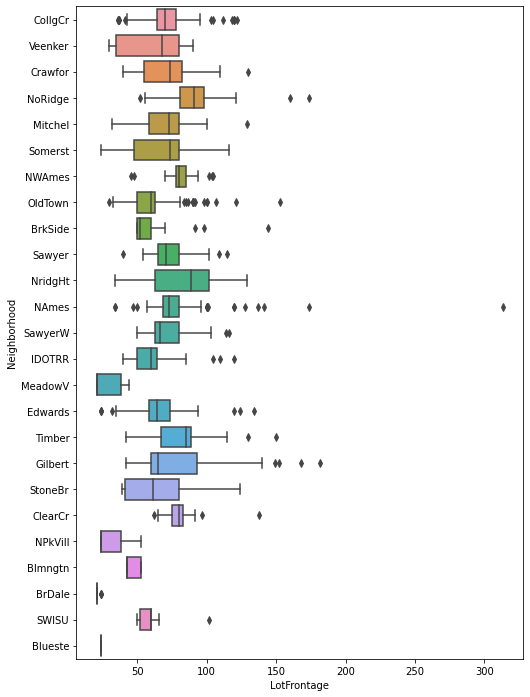

In [39]:
plt.figure(figsize=(8, 12))
sns.boxplot(data=Train, x='LotFrontage', y='Neighborhood')

In [40]:
Train.groupby('Neighborhood')['LotFrontage'].mean()

Neighborhood
Blmngtn    47.142857
Blueste    24.000000
BrDale     21.562500
BrkSide    57.509804
ClearCr    83.461538
CollgCr    71.682540
Crawfor    71.804878
Edwards    64.811111
Gilbert    79.877551
IDOTRR     62.500000
MeadowV    27.800000
Mitchel    70.083333
NAmes      76.462366
NPkVill    32.285714
NWAmes     81.288889
NoRidge    91.878788
NridgHt    81.881579
OldTown    62.788991
SWISU      58.913043
Sawyer     74.437500
SawyerW    71.500000
Somerst    64.666667
StoneBr    62.700000
Timber     80.379310
Veenker    59.714286
Name: LotFrontage, dtype: float64

In [41]:
Train['LotFrontage']= Train.groupby('Neighborhood')['LotFrontage'].transform(lambda val: val.fillna(val.mean()))

In [42]:
Train['LotFrontage']= Train['LotFrontage'].fillna(0)

In [43]:
nan_percent= missing_percent(Train)

In [44]:
nan_percent

Series([], dtype: float64)

In [45]:
Train.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,RL,65.0,8450,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,2,2008,WD,Normal,208500
1,20,RL,80.0,9600,Pave,Reg,Lvl,AllPub,FR2,Gtl,...,0,0,0,0,0,5,2007,WD,Normal,181500
2,60,RL,68.0,11250,Pave,IR1,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,9,2008,WD,Normal,223500
3,70,RL,60.0,9550,Pave,IR1,Lvl,AllPub,Corner,Gtl,...,272,0,0,0,0,2,2006,WD,Abnorml,140000
4,60,RL,84.0,14260,Pave,IR1,Lvl,AllPub,FR2,Gtl,...,0,0,0,0,0,12,2008,WD,Normal,250000


In [46]:
Train.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1457 entries, 0 to 1459
Data columns (total 76 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1457 non-null   int64  
 1   MSZoning       1457 non-null   object 
 2   LotFrontage    1457 non-null   float64
 3   LotArea        1457 non-null   int64  
 4   Street         1457 non-null   object 
 5   LotShape       1457 non-null   object 
 6   LandContour    1457 non-null   object 
 7   Utilities      1457 non-null   object 
 8   LotConfig      1457 non-null   object 
 9   LandSlope      1457 non-null   object 
 10  Neighborhood   1457 non-null   object 
 11  Condition1     1457 non-null   object 
 12  Condition2     1457 non-null   object 
 13  BldgType       1457 non-null   object 
 14  HouseStyle     1457 non-null   object 
 15  OverallQual    1457 non-null   int64  
 16  OverallCond    1457 non-null   int64  
 17  YearBuilt      1457 non-null   int64  
 18  YearRemo

In [47]:
Train['MSSubClass']= Train['MSSubClass'].apply(str)

In [48]:
Train.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1457 entries, 0 to 1459
Data columns (total 76 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1457 non-null   object 
 1   MSZoning       1457 non-null   object 
 2   LotFrontage    1457 non-null   float64
 3   LotArea        1457 non-null   int64  
 4   Street         1457 non-null   object 
 5   LotShape       1457 non-null   object 
 6   LandContour    1457 non-null   object 
 7   Utilities      1457 non-null   object 
 8   LotConfig      1457 non-null   object 
 9   LandSlope      1457 non-null   object 
 10  Neighborhood   1457 non-null   object 
 11  Condition1     1457 non-null   object 
 12  Condition2     1457 non-null   object 
 13  BldgType       1457 non-null   object 
 14  HouseStyle     1457 non-null   object 
 15  OverallQual    1457 non-null   int64  
 16  OverallCond    1457 non-null   int64  
 17  YearBuilt      1457 non-null   int64  
 18  YearRemo

In [49]:
Train.select_dtypes(include='object')

,MSSubClass,MSZoning,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,...,KitchenQual,Functional,FireplaceQu,GarageType,GarageFinish,GarageQual,GarageCond,PavedDrive,SaleType,SaleCondition
0,60,RL,Pave,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,...,Gd,Typ,None,Attchd,RFn,TA,TA,Y,WD,Normal
1,20,RL,Pave,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,...,TA,Typ,TA,Attchd,RFn,TA,TA,Y,WD,Normal
2,60,RL,Pave,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,...,Gd,Typ,TA,Attchd,RFn,TA,TA,Y,WD,Normal
3,70,RL,Pave,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,...,Gd,Typ,Gd,Detchd,Unf,TA,TA,Y,WD,Abnorml
4,60,RL,Pave,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,...,Gd,Typ,TA,Attchd,RFn,TA,TA,Y,WD,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,60,RL,Pave,Reg,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,...,TA,Typ,TA,Attchd,RFn,TA,TA,Y,WD,Normal
1456,20,RL,Pave,Reg,Lvl,AllPub,Inside,Gtl,NWAmes,Norm,...,TA,Min1,TA,Attchd,Unf,TA,TA,Y,WD,Normal
1457,70,RL,Pave,Reg,Lvl,AllPub,Inside,Gtl,Crawfor,Norm,...,Gd,Typ,Gd,Attchd,RFn,TA,TA,Y,WD,Normal
1458,20,RL,Pave,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,...,Gd,Typ,None,Attchd,Unf,TA,TA,Y,WD,Normal


In [50]:
Train_num= Train.select_dtypes(exclude='object')
Train_obj= Train.select_dtypes(exclude='object')

In [51]:
Train_obj= pd.get_dummies(Train_obj, drop_first=True)

In [52]:
Train_obj.shape

(1457, 36)

In [53]:
Train_num.shape

(1457, 36)

In [54]:
Final_Train= pd.concat([Train_num, Train_obj], axis=1)

In [55]:
Final_Train.shape

(1457, 72)